### Pre-processing, Training and Modelling -- Capstone 3 -- Heart Disease

# Heart Disease Prediction using Machine Learning
### Suniksha Gupta
Materials Science & Data Science |
Date: February 2026


## 1. Problem Statement

Cardiovascular disease is one of the leading causes of death globally. 
The objective of this project is to build a machine learning model 
to predict the presence of heart disease based on clinical parameters.


## 2. Dataset Description

The dataset contains clinical attributes such as:
- Age
- Gender
- Blood Pressure
- Cholesterol Level
- Exercise Habits
- Smoking
- Family Heart Disease
- Diabetes
- BMI
- High LDL Cholesterol
- Alcohol Consumption
- Stress Level
- Sleep Hours
- Sugar Consumption
- Triglyceride Level
- Fasting Blood Sugar
- CRP Level
- Homocysteine Level
- Heart Disease Status

In [60]:
# Importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## 3. Data Loading


In [61]:
df=pd.read_csv(r"D:\Data_Science\Capstone Project-3\Heart_Disease\EDA_data.csv")
df.head()

,Unnamed: 0,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
1,2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
2,3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
3,4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No
4,5,25.0,Male,152.0,257.0,Low,Yes,No,No,28.144681,...,No,Low,Medium,5.504876,Low,126.0,91.0,4.297575,10.815983,No


In [62]:
# Create dummy or indicator features for categorical variables
# Standardize the magnitude of numeric features using a scaler
# Split your data into testing and training datasets

## 4. Data Preprocessing


In [63]:
df.shape

(9532, 22)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9532 entries, 0 to 9531
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            9532 non-null   int64  
 1   Age                   9532 non-null   float64
 2   Gender                9532 non-null   object 
 3   Blood Pressure        9532 non-null   float64
 4   Cholesterol Level     9532 non-null   float64
 5   Exercise Habits       9532 non-null   object 
 6   Smoking               9532 non-null   object 
 7   Family Heart Disease  9532 non-null   object 
 8   Diabetes              9532 non-null   object 
 9   BMI                   9532 non-null   float64
 10  High Blood Pressure   9532 non-null   object 
 11  Low HDL Cholesterol   9532 non-null   object 
 12  High LDL Cholesterol  9532 non-null   object 
 13  Alcohol Consumption   9532 non-null   object 
 14  Stress Level          9532 non-null   object 
 15  Sleep Hours          

In [65]:
#checking the missing values
df.isnull().sum()

Unnamed: 0              0
Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
Heart Disease Status    0
dtype: int64

In [66]:
df.nunique()

Unnamed: 0              9532
Age                       63
Gender                     2
Blood Pressure            61
Cholesterol Level        151
Exercise Habits            3
Smoking                    2
Family Heart Disease       2
Diabetes                   2
BMI                     9532
High Blood Pressure        2
Low HDL Cholesterol        2
High LDL Cholesterol       2
Alcohol Consumption        4
Stress Level               3
Sleep Hours             9532
Sugar Consumption          3
Triglyceride Level       301
Fasting Blood Sugar       81
CRP Level               9532
Homocysteine Level      9532
Heart Disease Status       2
dtype: int64

**Converting categorical variables to numerical**

In [67]:
df.columns

Index(['Unnamed: 0', 'Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='object')

In [68]:
categorical = ['Gender','Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes',
              'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sugar Consumption', 'Heart Disease Status']
for col in categorical: 
    print(f"{col}: {df[col].unique()}")

Gender: ['Female' 'Male']
Exercise Habits: ['High' 'Low' 'Medium']
Smoking: ['No' 'Yes']
Family Heart Disease: ['Yes' 'No']
Diabetes: ['Yes' 'No']
High Blood Pressure: ['No' 'Yes']
Low HDL Cholesterol: ['Yes' 'No']
High LDL Cholesterol: ['No' 'Yes']
Alcohol Consumption: ['Medium' 'Low' 'Unknown' 'High']
Stress Level: ['High' 'Low' 'Medium']
Sugar Consumption: ['Medium' 'Low' 'High']
Heart Disease Status: ['No' 'Yes']


In [69]:
#replacing categorical features to numeric 
df['Gender'].replace(['Female', 'Male'], [0, 1], inplace = True)
df['Exercise Habits'].replace(["Low", "Medium", "High"], [0,1,2], inplace = True)
df['Smoking'].replace(["Yes", "No"], [0,1], inplace = True)
df['Family Heart Disease'].replace(["Yes", "No"], [0,1], inplace = True)
df['Diabetes'].replace(["Yes", "No"], [0,1], inplace = True)
df['High Blood Pressure'].replace(["Yes", "No"], [0,1], inplace = True)
df['Low HDL Cholesterol'].replace(["Yes", "No"], [0,1], inplace = True)
df['High LDL Cholesterol'].replace(["Yes", "No"], [0,1], inplace = True)
df['Alcohol Consumption'].replace(["Low", "Medium", "High", "Unknown"], [0,1,2, -1], inplace = True)
df['Stress Level'].replace(["Low", "Medium", "High"], [0,1,2], inplace = True)
df['Sugar Consumption'].replace(["Low", "Medium", "High"], [0,1,2], inplace = True)
df['Heart Disease Status'].replace(["Yes", "No"], [0,1], inplace = True)

C:\Users\User\AppData\Local\Temp\ipykernel_16084\1543917756.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace(['Female', 'Male'], [0, 1], inplace = True)
C:\Users\User\AppData\Local\Temp\ipykernel_16084\1543917756.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'

In [70]:
df.dtypes

Unnamed: 0                int64
Age                     float64
Gender                    int64
Blood Pressure          float64
Cholesterol Level       float64
Exercise Habits           int64
Smoking                   int64
Family Heart Disease      int64
Diabetes                  int64
BMI                     float64
High Blood Pressure       int64
Low HDL Cholesterol       int64
High LDL Cholesterol      int64
Alcohol Consumption       int64
Stress Level              int64
Sleep Hours             float64
Sugar Consumption         int64
Triglyceride Level      float64
Fasting Blood Sugar     float64
CRP Level               float64
Homocysteine Level      float64
Heart Disease Status      int64
dtype: object

In [71]:
df.isnull().sum()

Unnamed: 0              0
Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
Heart Disease Status    0
dtype: int64

In [72]:
df.columns

Index(['Unnamed: 0', 'Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='object')

In [73]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [74]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,69.0,0,146.0,286.0,2,1,0,0,25.221799,1,...,1,1,2,8.744034,1,133.0,157.0,9.355389,19.298875,1
1,46.0,1,126.0,216.0,0,1,1,1,29.855447,1,...,0,0,0,4.440440,0,393.0,92.0,12.709873,11.230926,1
2,32.0,0,122.0,293.0,2,0,0,1,24.130477,0,...,0,0,2,5.249405,2,293.0,94.0,12.509046,5.961958,1
3,60.0,1,166.0,242.0,0,0,0,0,20.486289,0,...,1,0,2,7.030971,2,263.0,154.0,10.381259,8.153887,1
4,25.0,1,152.0,257.0,0,0,1,1,28.144681,1,...,1,0,1,5.504876,0,126.0,91.0,4.297575,10.815983,1


In [75]:
df.columns

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='object')

**#feature engineering**

In [76]:
#A. Age-based features
df['age_group'] = pd.cut(df['Age'], bins=[0, 35, 50, 65, 100], 
                         labels=['Young', 'Middle', 'Senior', 'Elderly'])
df['age_high_bp'] = df['Age'] * df['Blood Pressure'].map({'No':0,'Yes':1})


In [77]:
#b. BMI-based features
df['bmi_category']=pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 100],
                          labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

In [78]:
#c. cholestrol and lipid risk features
df['lipid_risk']=(df['High LDL Cholesterol'].map({'Yes':1, 'No':0})+
                  df['Low HDL Cholesterol'].map({'Yes':1, 'No':0})
                 )
df['cholesterol_risk_flag'] = ((df['Cholesterol Level'] > 240).astype(int))

In [79]:
#d. Metabolic syndrome indicators
df['metabolic_risk'] = (
    (df['BMI'] > 30).astype(int) +
    (df['Fasting Blood Sugar'] > 126).astype(int) +
    df['Diabetes'].map({'Yes':1,'No':0}) +
    df['High Blood Pressure'].map({'Yes':1,'No':0})
)

In [80]:
#e.Lifestyle risk features
df['lifestyle_risk'] = (
    df['Smoking'].map({'Yes':1,'No':0}) +
    df['Alcohol Consumption'].map({'High':2,'Medium':1,'Low':0}) +
    df['Exercise Habits'].map({'Low':2,'Medium':1,'High':0})
)

In [81]:
df.columns

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status', 'age_group',
       'age_high_bp', 'bmi_category', 'lipid_risk', 'cholesterol_risk_flag',
       'metabolic_risk', 'lifestyle_risk'],
      dtype='object')

In [82]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,CRP Level,Homocysteine Level,Heart Disease Status,age_group,age_high_bp,bmi_category,lipid_risk,cholesterol_risk_flag,metabolic_risk,lifestyle_risk
0,69.0,0,146.0,286.0,2,1,0,0,25.221799,1,...,9.355389,19.298875,1,Elderly,NaN,Overweight,NaN,1,NaN,NaN
1,46.0,1,126.0,216.0,0,1,1,1,29.855447,1,...,12.709873,11.230926,1,Middle,NaN,Overweight,NaN,0,NaN,NaN
2,32.0,0,122.0,293.0,2,0,0,1,24.130477,0,...,12.509046,5.961958,1,Young,NaN,Normal,NaN,1,NaN,NaN
3,60.0,1,166.0,242.0,0,0,0,0,20.486289,0,...,10.381259,8.153887,1,Senior,NaN,Normal,NaN,1,NaN,NaN
4,25.0,1,152.0,257.0,0,0,1,1,28.144681,1,...,4.297575,10.815983,1,Young,NaN,Overweight,NaN,1,NaN,NaN


In [83]:
#Replacing new features with numeirc values
df['age_group'].replace(['Young', 'Middle', 'Senior', 'Elderly'], [0, 1, 2, 3], inplace=True)
df['bmi_category'].replace(['Underweight', 'Normal', 'Overweight', 'Obese'], [0, 1, 2, 3], 
inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_16084\3898420990.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age_group'].replace(['Young', 'Middle', 'Senior', 'Elderly'], [0, 1, 2, 3], inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_16084\3898420990.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downc

In [84]:
df.dtypes

Age                       float64
Gender                      int64
Blood Pressure            float64
Cholesterol Level         float64
Exercise Habits             int64
Smoking                     int64
Family Heart Disease        int64
Diabetes                    int64
BMI                       float64
High Blood Pressure         int64
Low HDL Cholesterol         int64
High LDL Cholesterol        int64
Alcohol Consumption         int64
Stress Level                int64
Sleep Hours               float64
Sugar Consumption           int64
Triglyceride Level        float64
Fasting Blood Sugar       float64
CRP Level                 float64
Homocysteine Level        float64
Heart Disease Status        int64
age_group                category
age_high_bp               float64
bmi_category             category
lipid_risk                float64
cholesterol_risk_flag       int32
metabolic_risk            float64
lifestyle_risk            float64
dtype: object

In [85]:
#checking correlation of feature with target variable
corr = df.corr()['Heart Disease Status'].sort_values(ascending=False)
corr

Heart Disease Status     1.000000
Gender                   0.017346
Blood Pressure           0.014643
High LDL Cholesterol     0.009397
age_group                0.007785
CRP Level                0.006405
Age                      0.005652
Fasting Blood Sugar      0.005172
Smoking                  0.003901
Cholesterol Level        0.000481
High Blood Pressure      0.000365
Sleep Hours             -0.000302
cholesterol_risk_flag   -0.001897
Exercise Habits         -0.002038
Triglyceride Level      -0.002314
Low HDL Cholesterol     -0.004251
Diabetes                -0.004654
Family Heart Disease    -0.008642
Homocysteine Level      -0.008731
Alcohol Consumption     -0.012329
Sugar Consumption       -0.013039
Stress Level            -0.014703
BMI                     -0.021139
bmi_category            -0.023142
age_high_bp                   NaN
lipid_risk                    NaN
metabolic_risk                NaN
lifestyle_risk                NaN
Name: Heart Disease Status, dtype: float64

In [86]:
df.isna().sum()

Age                         0
Gender                      0
Blood Pressure              0
Cholesterol Level           0
Exercise Habits             0
Smoking                     0
Family Heart Disease        0
Diabetes                    0
BMI                         0
High Blood Pressure         0
Low HDL Cholesterol         0
High LDL Cholesterol        0
Alcohol Consumption         0
Stress Level                0
Sleep Hours                 0
Sugar Consumption           0
Triglyceride Level          0
Fasting Blood Sugar         0
CRP Level                   0
Homocysteine Level          0
Heart Disease Status        0
age_group                   0
age_high_bp              9532
bmi_category                0
lipid_risk               9532
cholesterol_risk_flag       0
metabolic_risk           9532
lifestyle_risk           9532
dtype: int64

In [87]:
df.drop(columns=['age_high_bp', 'lipid_risk', 'metabolic_risk', 'lifestyle_risk', 'age_group', 'bmi_category'], inplace=True)

In [88]:
# df.drop(columns=['Low HDL Cholesterol', 'High Blood Pressure', 'Stress Level', 'Exercise Habits', 'Cholesterol Level', 'Diabetes', 'bmi_category', 
#                  'Homocysteine Level', 'Family Heart Disease', 'Alcohol Consumption', 'Sugar Consumption', 'BMI', 'Age'], inplace=True)

In [89]:
df.columns

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status',
       'cholesterol_risk_flag'],
      dtype='object')

In [90]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,cholesterol_risk_flag
0,69.0,0,146.0,286.0,2,1,0,0,25.221799,1,...,1,2,8.744034,1,133.0,157.0,9.355389,19.298875,1,1
1,46.0,1,126.0,216.0,0,1,1,1,29.855447,1,...,0,0,4.440440,0,393.0,92.0,12.709873,11.230926,1,0
2,32.0,0,122.0,293.0,2,0,0,1,24.130477,0,...,0,2,5.249405,2,293.0,94.0,12.509046,5.961958,1,1
3,60.0,1,166.0,242.0,0,0,0,0,20.486289,0,...,0,2,7.030971,2,263.0,154.0,10.381259,8.153887,1,1
4,25.0,1,152.0,257.0,0,0,1,1,28.144681,1,...,0,1,5.504876,0,126.0,91.0,4.297575,10.815983,1,1


# 5. Splitting Data



In [91]:
from sklearn.model_selection import train_test_split

X=df.drop(columns=['Heart Disease Status', ])
y=df['Heart Disease Status']
y.value_counts()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

## 6. Handling Class Imbalance using SMOTENC

The dataset shows class imbalance in the target variable 
(Heart Disease Status). To address this issue, we apply 
SMOTENC (Synthetic Minority Oversampling Technique for 
Nominal and Continuous features).

SMOTENC is specifically used because the dataset contains 
both categorical and numerical features.

Categorical Features Included:
- Gender
- Exercise Habits
- Smoking
- Family Heart Disease
- Diabetes
- Alcohol Consumption
- High Blood Pressure
- Sugar Consumption
- Low HDL Cholesterol
- High LDL Cholesterol
- cholesterol_risk_flag
- Stress Level

This step generates synthetic samples for the minority class 
while preserving categorical feature distributions.


In [92]:
from imblearn.over_sampling import SMOTENC

categorical_features = [
    'Gender', 'Exercise Habits', 'Smoking',
    'Family Heart Disease', 'Diabetes', 'Alcohol Consumption', 
    'High Blood Pressure', 'Sugar Consumption', 'Low HDL Cholesterol', 'High LDL Cholesterol',
    'cholesterol_risk_flag', 'Stress Level', 
]

cat_indices = [X.columns.get_loc(col) for col in categorical_features]

smote = SMOTENC(
    categorical_features=cat_indices,
    random_state=42
)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


In [93]:
# from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=42)
# X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [94]:
y_train_sm.value_counts()

Heart Disease Status
0    6093
1    6093
Name: count, dtype: int64

In [95]:
X_train_sm.isnull().sum()

Age                      0
Gender                   0
Blood Pressure           0
Cholesterol Level        0
Exercise Habits          0
Smoking                  0
Family Heart Disease     0
Diabetes                 0
BMI                      0
High Blood Pressure      0
Low HDL Cholesterol      0
High LDL Cholesterol     0
Alcohol Consumption      0
Stress Level             0
Sleep Hours              0
Sugar Consumption        0
Triglyceride Level       0
Fasting Blood Sugar      0
CRP Level                0
Homocysteine Level       0
cholesterol_risk_flag    0
dtype: int64

## 7. Scaling Numerical Features with StandardScaler

We scale only the continuous (numerical) features to standardize 
their ranges. This helps machine learning algorithms converge faster 
and perform better.  

**Numerical features scaled:**
- Age
- Blood Pressure
- Cholesterol Level
- BMI
- Sleep Hours
- Triglyceride Level
- Fasting Blood Sugar
- CRP Level
- Homocysteine Level

Categorical features are excluded from scaling.


In [96]:
num_features = [
    'Age', 'Blood Pressure', 'Cholesterol Level',
    'BMI', 'Sleep Hours', 'Triglyceride Level',
    'Fasting Blood Sugar', 'CRP Level',
    'Homocysteine Level'
]

scaler = StandardScaler()

X_train_sm[num_features] = scaler.fit_transform(X_train_sm[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

In [97]:
# # #scale data
# from sklearn import preprocessing
# from sklearn.preprocessing import StandardScaler
# import numpy as np
# # build scaler based on training data and apply it to test data to then also scale the test data
# scaler = preprocessing.StandardScaler().fit(X_train_sm)
# X_train_scaled=scaler.transform(X_train_sm)
# X_test_scaled=scaler.transform(X_test)

## 8. Feature Importance from Random Forest

Random Forest provides a measure of feature importance based on how much 
each feature decreases the impurity across all trees.  

We use this to identify the **top 10 features** that contribute most 
to predicting heart disease.


In [98]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_sm, y_train_sm)

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(10)
top_features

CRP Level              0.096037
Sleep Hours            0.093715
Homocysteine Level     0.093246
BMI                    0.092960
Fasting Blood Sugar    0.091022
Age                    0.089250
Triglyceride Level     0.085958
Cholesterol Level      0.085542
Blood Pressure         0.084257
Alcohol Consumption    0.027776
dtype: float64

C:\Users\User\AppData\Local\Temp\ipykernel_16084\2817869118.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


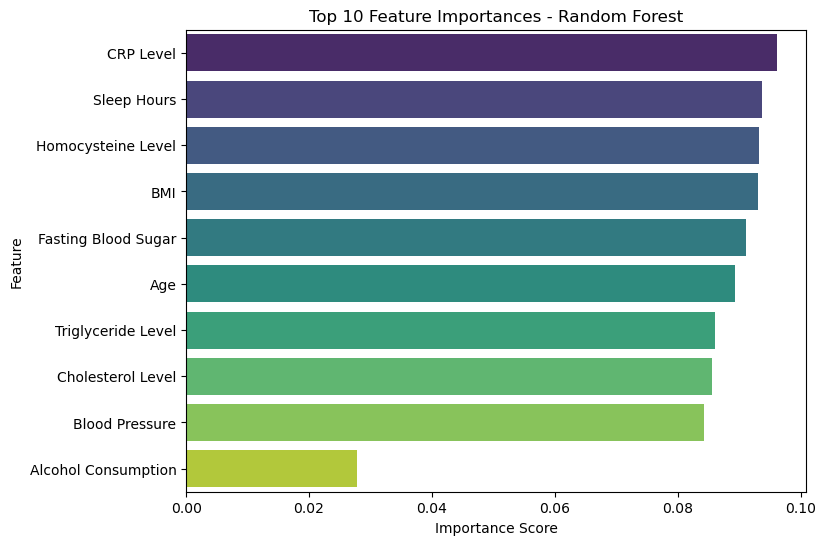

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

**Model: 0 Dummy Regressor**

## 9. Baseline Model using Dummy Classifier

To evaluate the performance of our Random Forest model, 
we first establish a **baseline** using a Dummy Classifier.

**Why Dummy Classifier?**
- Provides a reference performance using simple strategies.
- Helps determine if our ML model is actually learning patterns 
  beyond random chance.

**Strategy options:**
- `most_frequent` → always predicts the majority class
- `stratified` → predicts randomly but preserves class distribution


Dummy Classifier Accuracy: 0.1987

Classification Report:
               precision    recall  f1-score   support

           0       0.20      1.00      0.33       379
           1       0.00      0.00      0.00      1528

    accuracy                           0.20      1907
   macro avg       0.10      0.50      0.17      1907
weighted avg       0.04      0.20      0.07      1907



C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


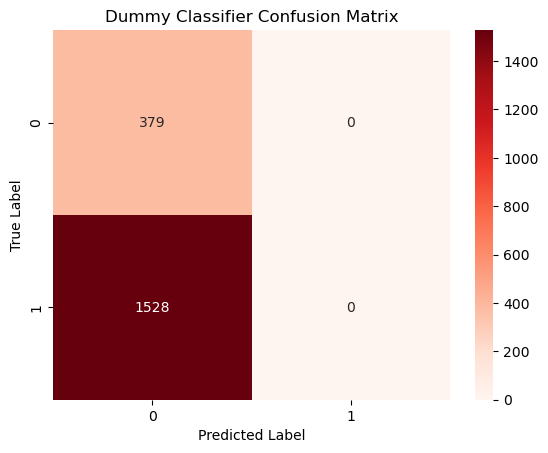

In [100]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_train_cr = y_train_sm / 1e7
y_test_cr = y_test / 1e7

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_sm, y_train_sm)

y_dummy_pred = dummy.predict(X_test)

# Evaluate accuracy
dummy_acc = accuracy_score(y_test, y_dummy_pred)
print("Dummy Classifier Accuracy:", round(dummy_acc, 4))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_dummy_pred))

# Confusion matrix
cm_dummy = confusion_matrix(y_test, y_dummy_pred)
sns.heatmap(cm_dummy, annot=True, fmt='d', cmap='Reds')
plt.title("Dummy Classifier Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [101]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

**Model 1: Logistic Regression**

## 10. Logistic Regression Classifier

We train a Logistic Regression model on the balanced and scaled dataset.  

**Why Logistic Regression?**
- Simple and interpretable model for binary classification
- Outputs probabilities for each class
- Provides coefficients to understand feature impact
- Good baseline to compare with Random Forest


Logistic Regression Accuracy: 0.5134

Classification Report:
               precision    recall  f1-score   support

           0       0.18      0.41      0.25       379
           1       0.79      0.54      0.64      1528

    accuracy                           0.51      1907
   macro avg       0.48      0.48      0.45      1907
weighted avg       0.67      0.51      0.56      1907



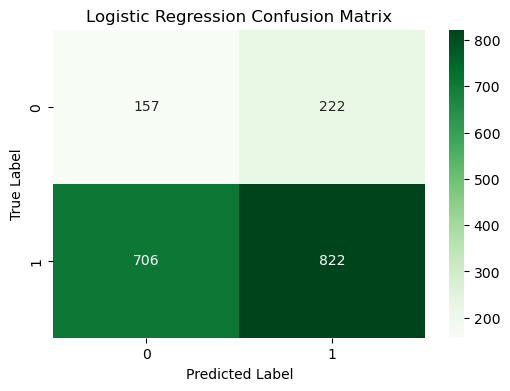

In [108]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize Logistic Regression
logreg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

# Train on SMOTENC-resampled and scaled training data
logreg.fit(X_train_sm, y_train_sm)

# Predict on test data
y_pred_logreg = logreg.predict(X_test)

# Evaluate accuracy
logreg_acc = accuracy_score(y_test, y_pred_logreg)
print("Logistic Regression Accuracy:", round(logreg_acc, 4))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_logreg))

# Confusion Matrix
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
plt.figure(figsize=(6,4))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Greens')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [109]:
from sklearn.metrics import roc_auc_score
y_proba = model.predict_proba(X_test)[:,1]
roc_auc=roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.3f}")

ROC-AUC: 0.481


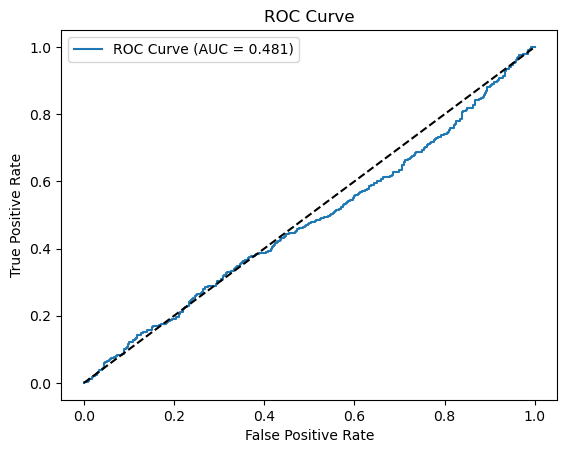

In [110]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 11. K-Nearest Neighbors (KNN) Classifier

We train a K-Nearest Neighbors (KNN) model on the balanced and scaled dataset.

**Why KNN?**
- Distance-based algorithm
- Works well when data is properly scaled
- Simple and non-parametric model
- Useful comparison against Logistic Regression and Random Forest

Since KNN is distance-based, feature scaling is essential.

Confusion Matrix:


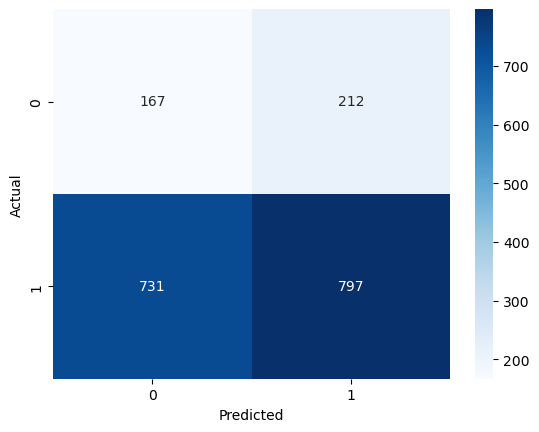

[[167 212]
 [731 797]]

Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.44      0.26       379
           1       0.79      0.52      0.63      1528

    accuracy                           0.51      1907
   macro avg       0.49      0.48      0.44      1907
weighted avg       0.67      0.51      0.56      1907


Model Accuracy: 0.51


In [126]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

knn = KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance')
knn.fit(X_train_sm, y_train_sm)
predictions = knn.predict(X_test)
print("Confusion Matrix:")

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))
print(f"\nModel Accuracy: {knn.score(X_test, y_test):.2f}")


## 12. KNN Hyperparameter Tuning with GridSearchCV

To improve KNN performance, we perform a **grid search** over:
- Number of neighbors (`n_neighbors`)
- Weighting strategy (`weights`)
- Distance metric (`metric`)

We use **5-fold cross-validation** and **weighted F1 score** 
as the scoring metric because the dataset is slightly imbalanced.

The goal is to find the combination of hyperparameters that 
maximizes model performance.


In [118]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='f1_weighted')
grid.fit(X_train_sm, y_train_sm)

print(grid.best_params_)
best_knn = grid.best_estimator_
best_knn

{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance')

## 13. KNN Hyperparameter Tuning with RandomizedSearchCV

RandomizedSearchCV allows us to:
- Explore a wider hyperparameter space efficiently
- Sample a fixed number of parameter settings randomly
- Reduce computation time compared to GridSearchCV

We tune the following parameters for KNN:
- `n_neighbors`: number of neighbors to consider
- `weights`: 'uniform' vs 'distance'
- `metric`: distance metric ('euclidean', 'manhattan')

We use 5-fold cross-validation and **weighted F1 score** to account for class imbalance.


In [122]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import randint

# Define parameter distribution
param_dist = {
    'n_neighbors': randint(3, 15),  # Random values between 3 and 15
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=param_dist,
    n_iter=20,              # number of random combinations to try
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1
)

# Fit on training data
random_search.fit(X_train_sm, y_train_sm)

# Best hyperparameters
print("Best KNN Hyperparameters (RandomizedSearch):", random_search.best_params_)

# Best estimator
best_knn_random = random_search.best_estimator_

Best KNN Hyperparameters (RandomizedSearch): {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}


## 14. Random Forest Classifier

We train a Random Forest Classifier on the balanced and scaled dataset.

**Why Random Forest?**
- Ensemble of decision trees reduces overfitting
- Handles numerical and categorical features well
- Provides feature importance for interpretability
- Robust to outliers and non-linear relationships

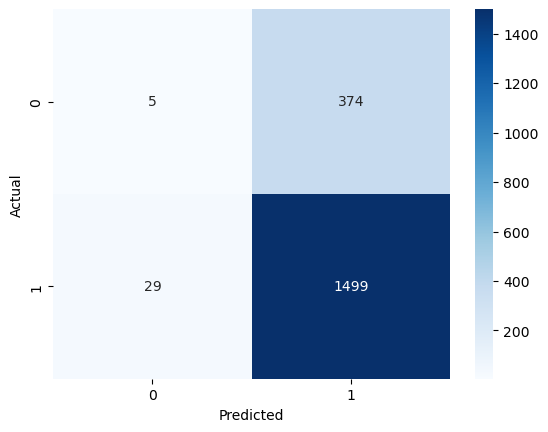

Model Accuracy: 0.7887

Classification Report:
              precision    recall  f1-score   support

           0       0.15      0.01      0.02       379
           1       0.80      0.98      0.88      1528

    accuracy                           0.79      1907
   macro avg       0.47      0.50      0.45      1907
weighted avg       0.67      0.79      0.71      1907



In [131]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rfc = RandomForestClassifier(random_state=42, n_estimators=100)
rfc.fit(X_train_sm, y_train_sm)
y_pred_rc = rfc.predict(X_test)

y_prob = rf.predict_proba(X_test)[:,1]
y_pred_ = (y_prob > 0.3).astype(int)  # try 0.2–0.4

accuracy = accuracy_score(y_test, y_pred_)
report = classification_report(y_test, y_pred_)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

Random Forest Accuracy: 0.6733

Classification Report:
               precision    recall  f1-score   support

           0       0.18      0.19      0.19       379
           1       0.80      0.79      0.80      1528

    accuracy                           0.67      1907
   macro avg       0.49      0.49      0.49      1907
weighted avg       0.68      0.67      0.67      1907



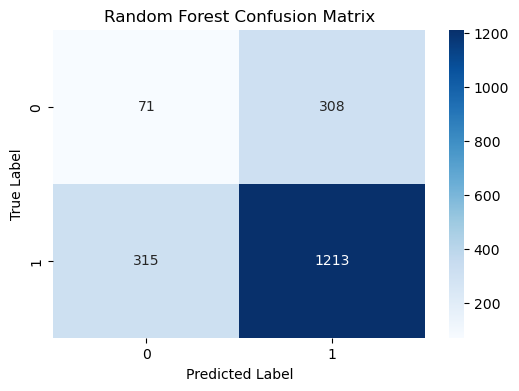

In [132]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)

# Train on SMOTENC-resampled and scaled training data
rf.fit(X_train_sm, y_train_sm)

# Predict on test data
y_pred_rf = rf.predict(X_test)

# Accuracy
rf_acc = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", round(rf_acc, 4))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
np.unique(y_pred_, return_counts=True)

In [ ]:
y_prob = rf.predict_proba(X_test)[:,1]

print(y_prob.min(), y_prob.max())

## 15. Random Forest Hyperparameter Tuning with RandomizedSearchCV

To improve Random Forest performance, we perform **RandomizedSearchCV**.  

**Parameters tuned:**
- `n_estimators` → Number of trees in the forest
- `max_depth` → Maximum depth of each tree
- `min_samples_split` → Minimum samples required to split a node
- `min_samples_leaf` → Minimum samples required at a leaf node
- `max_features` → Number of features considered for each split  

We use 5-fold cross-validation and **weighted F1 score** 
to account for class imbalance.  
RandomizedSearchCV allows us to efficiently explore a large 
hyperparameter space without trying all combinations.


In [134]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define the hyperparameter distribution
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None]
}

# Initialize RandomizedSearchCV
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,            # Number of random parameter combinations
    cv=5,                 # 5-fold cross-validation
    scoring='f1_weighted',# Weighted F1 accounts for class imbalance
    random_state=42,
    n_jobs=-1             # Use all available cores
)

# Fit on SMOTENC-resampled and scaled training data
rf_random_search.fit(X_train_sm, y_train_sm)

# Best hyperparameters
print("Best Random Forest Hyperparameters (Randomized Search):")
print(rf_random_search.best_params_)

# Best estimator
best_rf_random = rf_random_search.best_estimator_

Best Random Forest Hyperparameters (Randomized Search):
{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 426}


Tuned Random Forest Test Accuracy: 0.6198

Classification Report:
               precision    recall  f1-score   support

           0       0.17      0.24      0.20       379
           1       0.79      0.71      0.75      1528

    accuracy                           0.62      1907
   macro avg       0.48      0.48      0.48      1907
weighted avg       0.67      0.62      0.64      1907



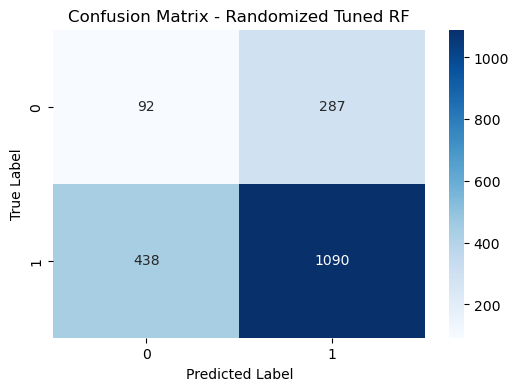

In [135]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test data
y_pred_best_rf = best_rf_random.predict(X_test)

# Accuracy
best_rf_acc = accuracy_score(y_test, y_pred_best_rf)
print("Tuned Random Forest Test Accuracy:", round(best_rf_acc, 4))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_best_rf))

# Confusion matrix
cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_best_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Randomized Tuned RF")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


## 16. Final Model Comparison

We compare all trained models on the test set using:

- Accuracy
- Weighted F1 score
- Confusion Matrix

This allows us to clearly see which model performs best for predicting heart disease.


In [136]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Dictionary of models
models = {
    "Dummy Classifier": dummy,
    "Logistic Regression": logreg,
    "KNN (default)": knn,
    "KNN (GridSearchCV)": best_knn,
    "Random Forest (default)": rf,
    "Random Forest (RandomizedSearchCV)": best_rf_random
}

# Store results
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Weighted F1 Score": round(f1, 4)
    })

# Convert to DataFrame
import pandas as pd
results_df = pd.DataFrame(results).sort_values(by="Weighted F1 Score", ascending=False)
print(results_df)

                                Model  Accuracy  Weighted F1 Score
4             Random Forest (default)    0.6733             0.6744
5  Random Forest (RandomizedSearchCV)    0.6198             0.6415
1                 Logistic Regression    0.5134             0.5624
2                       KNN (default)    0.5055             0.5554
3                  KNN (GridSearchCV)    0.5055             0.5554
0                    Dummy Classifier    0.1987             0.0659


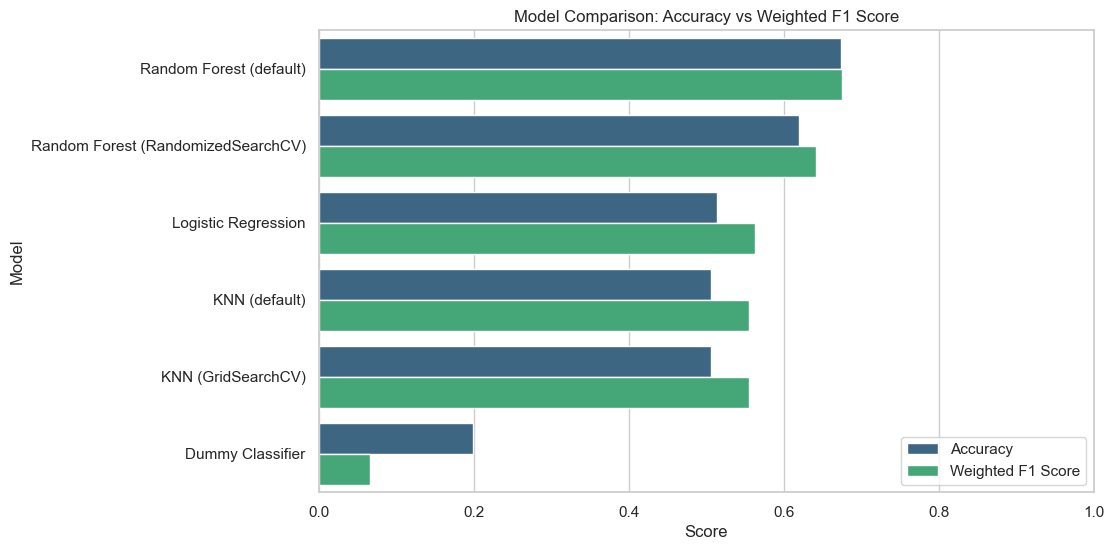

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Melt the dataframe for plotting
results_melted = results_df.melt(id_vars="Model", 
                                 value_vars=["Accuracy", "Weighted F1 Score"], 
                                 var_name="Metric", value_name="Score")

plt.figure(figsize=(10,6))
sns.barplot(x="Score", y="Model", hue="Metric", data=results_melted, palette="viridis")

plt.title("Model Comparison: Accuracy vs Weighted F1 Score")
plt.xlabel("Score")
plt.ylabel("Model")
plt.xlim(0,1)
plt.legend(loc="lower right")
plt.show()